<a href="https://colab.research.google.com/github/sthepaut/SAFRAN_ENSAI_2025/blob/ENSAI_students/performancemodel_ENSAI/notebook/genetic_algorithm_changes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# !git clone https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025
!git clone -b ENSAI_students https://github.com/Anonymous-GT11/SAFRAN_ENSAI_2025


fatal: destination path 'SAFRAN_ENSAI_2025' already exists and is not an empty directory.


In [2]:
# Verify that we have sucessfully clone the repo and go the place where the repo is stored
%cd /content/SAFRAN_ENSAI_2025
!ls


/content/SAFRAN_ENSAI_2025
Cie_0_Engine0.csv	    README.md
performancemodel_ENSAI	    SAFRAN_ENSAI_2025
performancemodel_ENSAI.zip  simple_genetic_algorithm_v3.py


In [1]:
# install the package performance_model
%cd /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI/
!pip install .

/content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
Processing /content/SAFRAN_ENSAI_2025/performancemodel_ENSAI
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for performancemodel: filename=performancemodel-0.0.1-py3-none-any.whl size=46484 sha256=5956ec8181356b404eb92df41c3f696ff1c21a95bb792810564eb3ad45d7851d
  Stored in directory: /tmp/pip-ephem-wheel-cache-39unaamz/wheels/b4/6e/66/25433221b4a4d2ead6faf834b0fa81054260e4a8996e629ab9
Successfully built performancemodel
  Attempting uninstall: performancemodel
    Found existing installation: performancemodel 0.0.1
    Uninstalling performancemodel-0.0.1:
      Successfully uninstalled performancemodel-0.0.1


In [2]:
%cd /content/SAFRAN_ENSAI_2025
!git pull


/content/SAFRAN_ENSAI_2025
Already up to date.


In [3]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import time
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm import tqdm

from performancemodel.base_system import h_SCSF
from performancemodel.scenarios import simulate_degradation_trajectory, generate_multiple_trajectories
from performancemodel.plot import plot_trajectory



In [4]:
from geneticalgorithms.simple_genetic_algorithm import GeneticAlgorithm
from geneticalgorithms.simple_genetic_algorithm import GeneticAlgorithmv2
from geneticalgorithms.simple_genetic_algorithm import GeneticAlgorithmv3

In [5]:
from geneticalgorithms.simple_genetic_algorithm import plot_final_fitness_map
from geneticalgorithms.simple_genetic_algorithm import plot_convergence_seaborn
from geneticalgorithms.simple_genetic_algorithm import plot_ga_population
from geneticalgorithms.simple_genetic_algorithm import plot_convergence
from geneticalgorithms.simple_genetic_algorithm import plot_ga_population
from geneticalgorithms.simple_genetic_algorithm import plot_ga_seaborn



#Estimate one measurement




In [6]:
# Example: Estimate one measurement
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=2, seed=0)
true_traj =np.asarray(true_traj, dtype=float)[:,:2]
sensors = ['P3', 'T5']

# Get measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[0]  # First measurement

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")

import time
start_time = time.time()
# Create and run GA
ga = GeneticAlgorithmv3(

    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=5,
    target_fitness=10.0,
    stagnation_generations=20,
    min_improvement=0.001
)

best_solution, fitness_history = ga.evolve()
print("end_time")
print ( time.time() - start_time )

print(f"\nEstimated health: [{best_solution[0].item():.4f}, {best_solution[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution.cpu().numpy())}")


True health: [1.00882026 1.00200079]
Target measurements: [1.79516603e+06 1.43208210e+03]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: inval

Gen 0: Best Fit = 5.71, Avg Fit = 3.06, Pop SD = 0.0201, Genes = [1.0119, 1.0007]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


end_time
180.9155580997467

Estimated health: [1.0082, 1.0023]
Error: [0.00059697 0.00030138]


In [7]:

import time
start_time = time.time()
# Create and run GA
ga1 = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=5
)

best_solution1, fitness_history1 = ga1.evolve()
print("end_time")
print ( time.time() - start_time )

print(f"\nEstimated health: [{best_solution1[0].item():.4f}, {best_solution1[1].item():.4f}]")
print(f"Error: {np.abs(np.array(true_traj[0]) - best_solution1.cpu().numpy())}")


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Generation 0: Fitness = -2.71, eta_comp = 1.0034, eta_turb = 0.9862
end_time
165.81347489356995

Estimated health: [1.0088, 1.0019]
Error: [1.90398823e-05 5.23102041e-05]


In [8]:
import math

error_0 = abs(true_traj[0][0] - best_solution[0].item())  # eta_comp error
error_1 = abs(true_traj[0][1] - best_solution[1].item())  # eta_turb error

print("Error on eta_comp:", error_0)
print("Error on eta_turb:", error_1)
error1_0 = abs(true_traj[0][0] - best_solution1[0].item())  # eta_comp error
error1_1 = abs(true_traj[0][1] - best_solution1[1].item())  # eta_turb error

print("Error on eta_comp pre-ver:", error1_0)
print("Error on eta_turb per-ver:", error1_1)

Error on eta_comp: 0.0005969665180463046
Error on eta_turb: 0.0003013837579686207
Error on eta_comp pre-ver: 1.903988230411713e-05
Error on eta_turb per-ver: 5.2310204128547255e-05


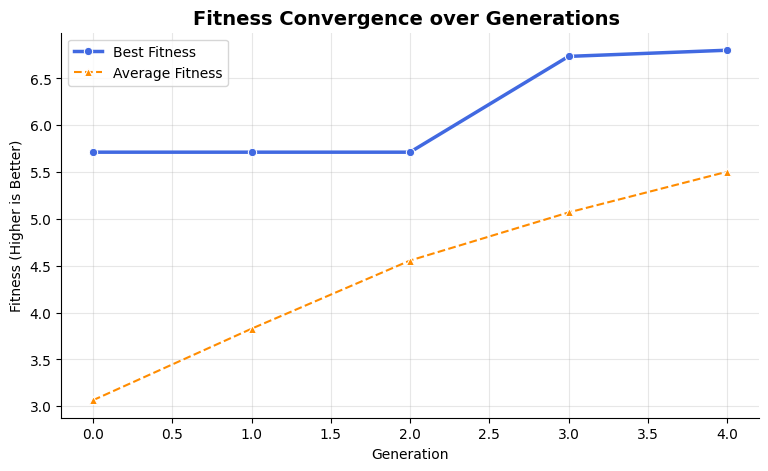

In [11]:
plot_convergence_seaborn(ga)

In [13]:
true_traj

array([[1.00882026, 1.00200079],
       [1.00872232, 1.00166389]])

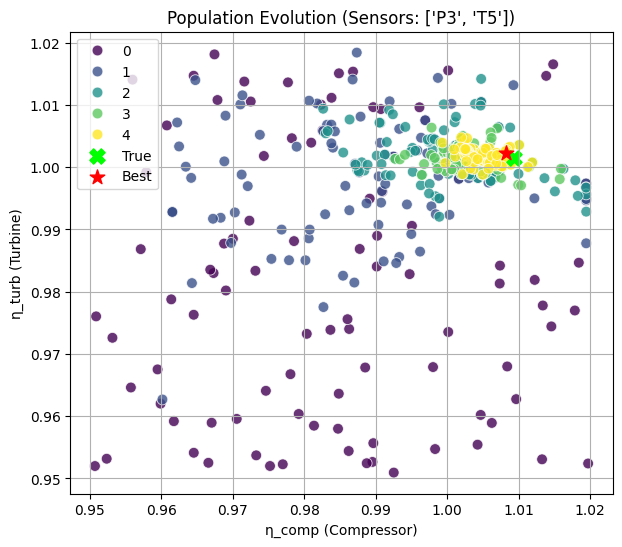

In [15]:
plot_ga_population(ga, best_solution, true_health=[1.0093, 1.0015])

#Estimate 3 components (comp, turb, comb) with GA
- P3
- T5
- Wf

In [ ]:
import time
import numpy as np

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)


sensors = ['P3', 'T5', 'Wf']

# Get simulated sensor measurements for first time step
measured_series = list(h_SCSF(true_traj, S=sensors))
target_measurements = measured_series[10]  # 55th sample

print(f"True health: {true_traj[0]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithmv3(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=20,
    bounds=[(0.95, 1.02)]*3,
    target_fitness=100.0,  # or None
    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")

/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health: [1.0088202617298383, 1.002000786041836, 1.0048936899205287]
Target measurements: [1.79246835e+06 1.44332123e+03 1.38101346e+00]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen 0: Best Fit = 6.99, Avg Fit = 2.51, Pop SD = 0.0195, Genes = [0.9957, 1.0026, 0.9932]
Gen 5: Best Fit = 7.25, Avg Fit = 6.22, Pop SD = 0.0029, Genes = [0.9957, 1.0028, 0.9929]
Gen 10: Best Fit = 7.30, Avg Fit = 6.92, Pop SD = 0.0010, Genes = [0.9937, 1.0039, 0.9910]
Gen 15: Best Fit = 7.51, Avg Fit = 7.21, Pop SD = 0.0004, Genes = [0.9944, 1.0037, 0.9916]

--- End of Evolution ---
Execution time: 276.95 s


In [ ]:
# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------

eta_comp_est, eta_turb_est,  eta_comb_est = best_solution.cpu().numpy()
true_eta_comp, true_eta_turb, true_eta_comb = true_traj[0]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}, η_comb={eta_comb_est:.4f}")
print(f"True health:       η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}, η_comb={true_eta_comb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)
error_comb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")
print(f"Error on η_turb: {error_comb:.6f}")



Estimated health: η_comp=0.9947, η_turb=1.0036, η_comb=0.9917
True health:       η_comp=1.0088, η_turb=1.0020, η_comb=1.0049
Error on η_comp: 0.014158
Error on η_turb: 0.001634
Error on η_turb: 0.001634


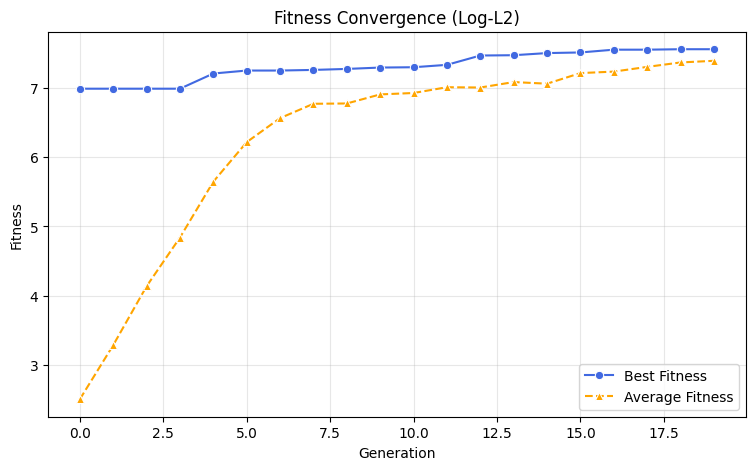

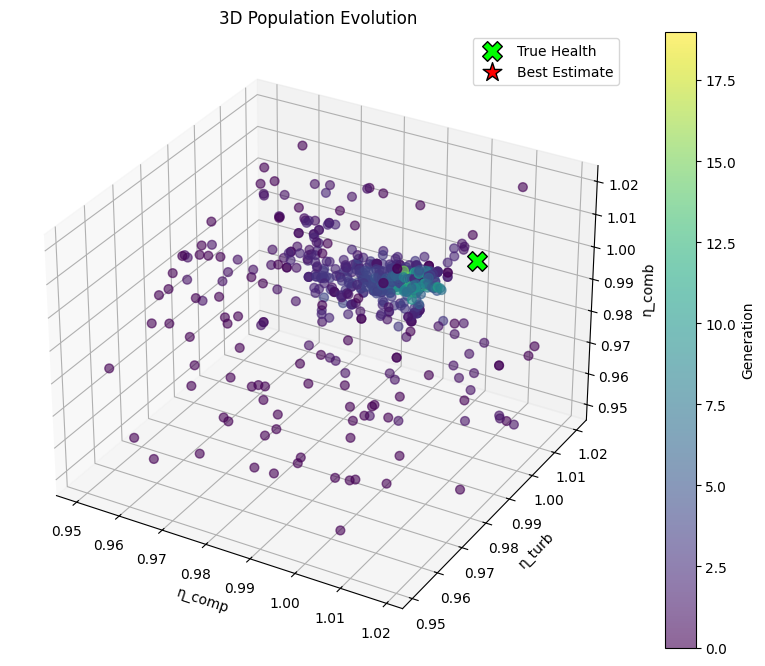

In [ ]:
# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
plot_convergence(ga)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb,  true_eta_comb])

#Estimate with 2 components (comp, turb, comb) with GA
- P3
- T5


In [ ]:
import time
import numpy as np

# ----------------------------------------------------------
# STEP 1 - Simulate True Health & Target Measurements
# ----------------------------------------------------------
true_traj = simulate_degradation_trajectory(speed='fast', waterwash='rare', size=100, seed=0)

# Slice to keep only 2 components (Compressor, Turbine)
true_traj = np.asarray(true_traj, dtype=float)[:, :2]

sensors = ['P3', 'T5']

# Get simulated sensor measurements
measured_series = list(h_SCSF(true_traj, S=sensors))

# Select the 10th sample for the target
target_idx = 10
target_measurements = measured_series[target_idx]

print(f"True health (at index {target_idx}): {true_traj[target_idx]}")
print(f"Target measurements: {target_measurements}")


# ----------------------------------------------------------
# STEP 2 — Create and Run the Genetic Algorithm
# ----------------------------------------------------------
start_time = time.time()

ga = GeneticAlgorithm(
    simulator=h_SCSF,
    target_measurements=target_measurements,
    sensors=sensors,
    pop_size=100,
    n_generations=20,
    bounds=[(0.95, 1.02), (0.95, 1.02)],

    target_fitness=10.0,
    min_improvement=0.005,

    mutation_rate=0.1,
    crossover_rate=0.9,
    tournament_size=3,
    n_elite=10,
    mutation_std_ratio=0.05
)

best_solution, fitness_history = ga.evolve(verbose_interval=5)

print("\n--- End of Evolution ---")
print(f"Execution time: {time.time() - start_time:.2f} s")


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


True health (at index 10): [1.00476525 0.99841178]
Target measurements: [1.79487724e+06 1.44407315e+03]


/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(
/usr/local/lib/python3.12/dist-packages/performancemodel/turboreactors.py:532: RuntimeWarning: invalid value encountered in sqrt
  self.M8 = np.sqrt(


Gen 0: Best Fit = 5.04, Avg Fit = 3.15, Pop SD = 0.0203, Genes = [1.0004, 0.9961]
Gen 5: Best Fit = 9.94, Avg Fit = 6.28, Pop SD = 0.0018, Genes = [1.0047, 0.9984]

STOPPING: Target fitness (10.00) achieved at Generation 6.

--- End of Evolution ---
Execution time: 106.05 s


In [ ]:
# ----------------------------------------------------------
# STEP 3 - Display Best Solution
# ----------------------------------------------------------
eta_comp_est, eta_turb_est = best_solution.cpu().numpy()

# CRITICAL FIX: Use the same index (10) as the target measurements!
true_eta_comp, true_eta_turb = true_traj[target_idx]

print(f"\nEstimated health: η_comp={eta_comp_est:.4f}, η_turb={eta_turb_est:.4f}")
print(f"True health:      η_comp={true_eta_comp:.4f}, η_turb={true_eta_turb:.4f}")

# Compute absolute errors
error_comp = abs(true_eta_comp - eta_comp_est)
error_turb = abs(true_eta_turb - eta_turb_est)

print(f"Error on η_comp: {error_comp:.6f}")
print(f"Error on η_turb: {error_turb:.6f}")


Estimated health: η_comp=1.0048, η_turb=0.9984
True health:      η_comp=1.0048, η_turb=0.9984
Error on η_comp: 0.000005
Error on η_turb: 0.000002


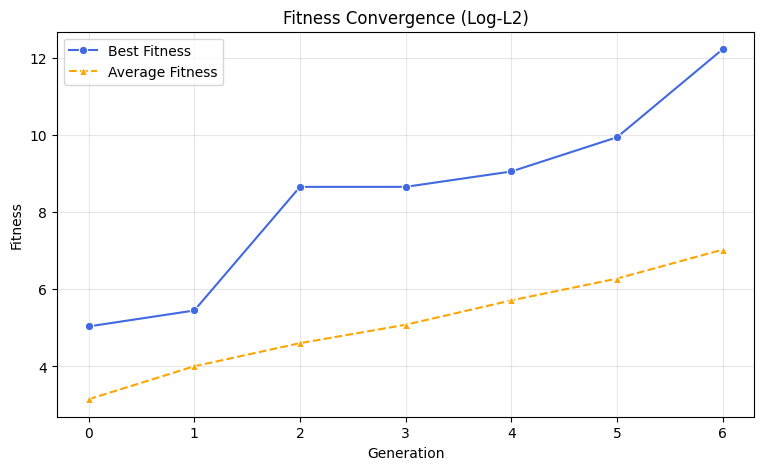

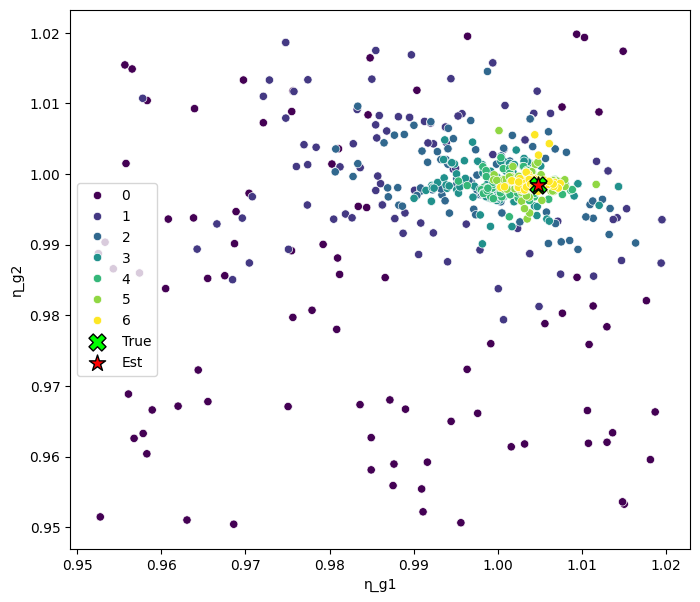

In [ ]:
# ----------------------------------------------------------
# STEP 4 — Visualizations
# ----------------------------------------------------------
# Plot convergence (Fitness is already Log-L2)
plot_convergence(ga)

# Visualize population (2D scatter)
plot_ga_population(ga, best_solution, true_health=[true_eta_comp, true_eta_turb])

#What was done

- change L1 norm into L2 norm
- Adapte Mutation
- Compute each 10 generation metrics
- Measur Stopping Criterion for each i and i+10 generation


We calculate the L2 norm of the error vector and also take the negative logarithm of Fitness: -log(L2_Error)
we did this because of error values near  zero

We adopted the scale of mutation (goes smaller across time), we defined a The decay factor that start from 1 for first generation and then goes smaller

We computed sd & average for each generation

We measured the improvement across generations(between generation i and i+10)
We compare the current best fitness with the fitness from stagnation_generations ago
